# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [2]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [3]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100) 

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) 
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

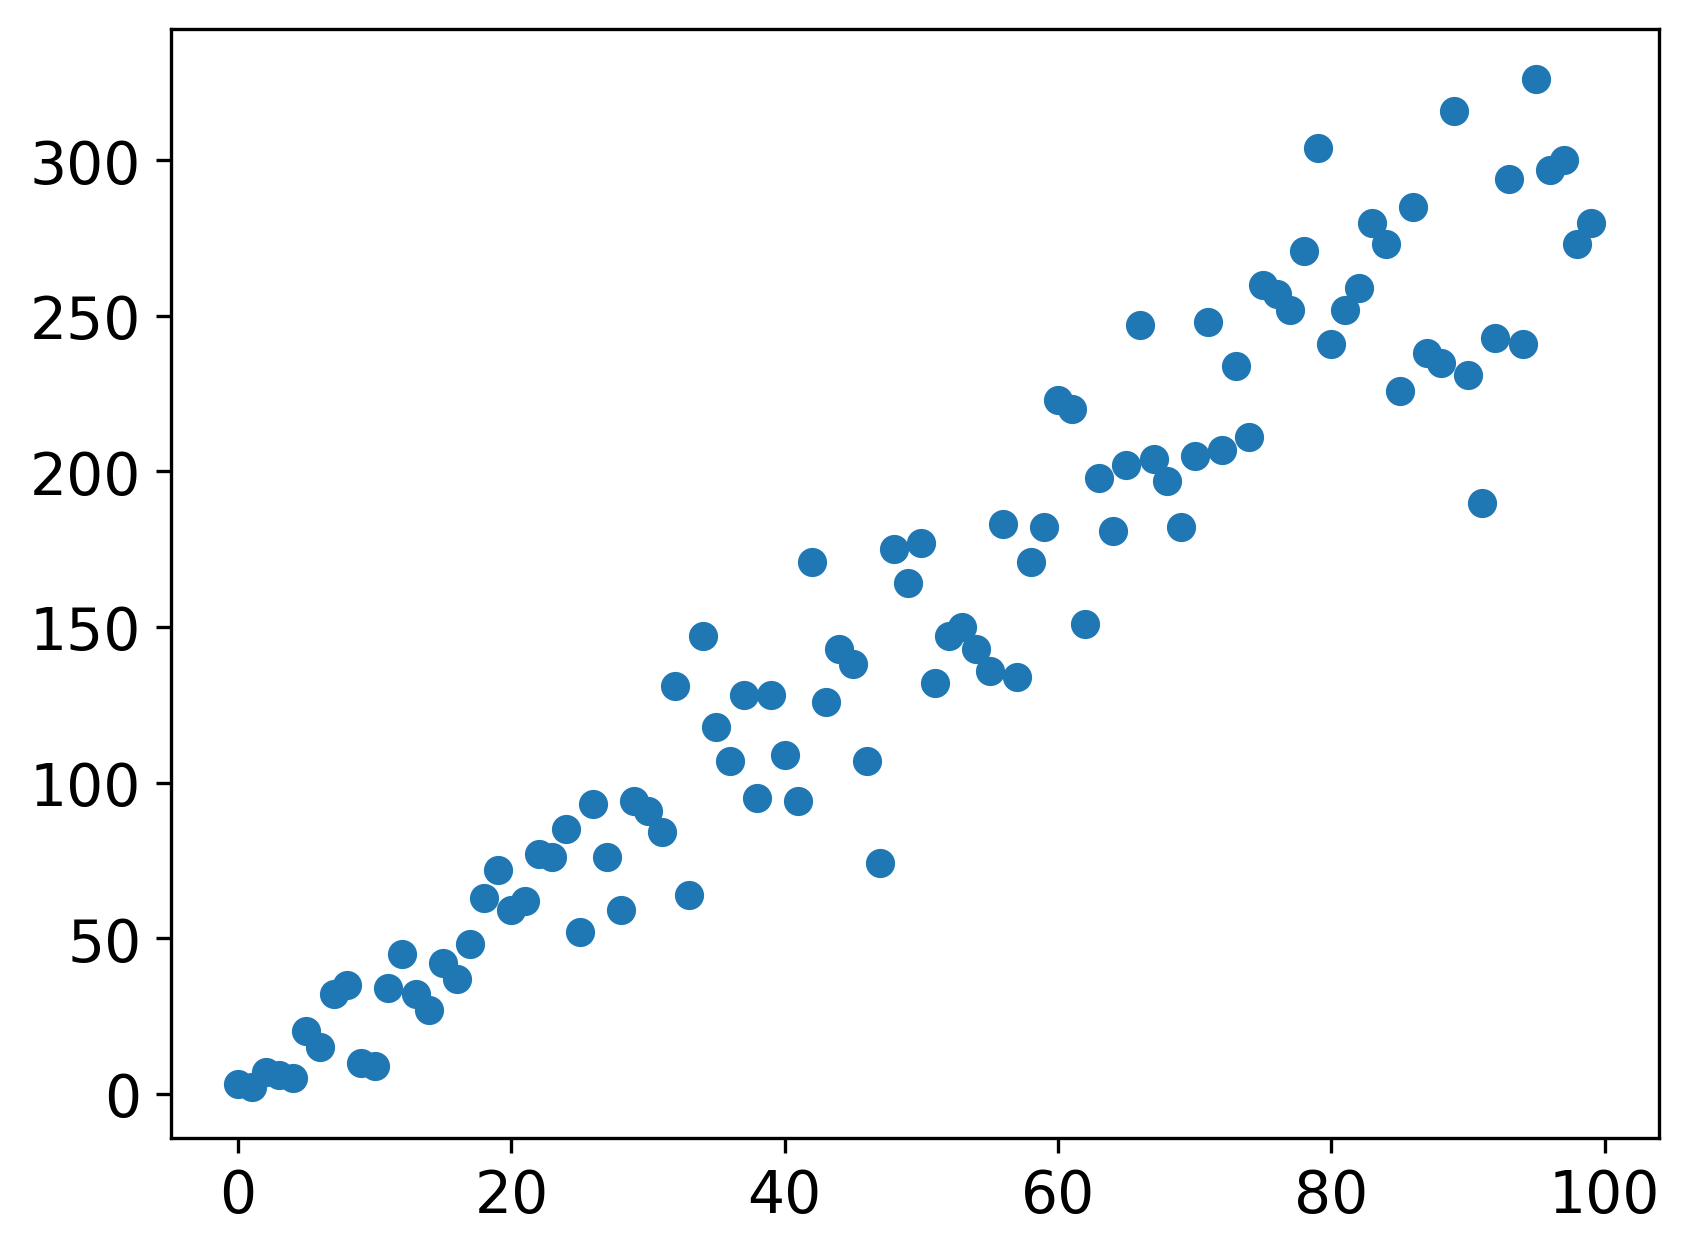

In [4]:
plt.scatter(x, yp);

### Pregunta 

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?
- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?
- ¿Qué podría implicar esto al mirar residuos más adelante?

___
### Respuesta
- Sí, sigue una tendencia lineal.
- No es constante, los valores se dispersan más a medida que aumenta el valor de $x$.
- Vamos a tener residuos más grandes.
___

In [5]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [6]:
model.fit(x.reshape(-1, 1), yp)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


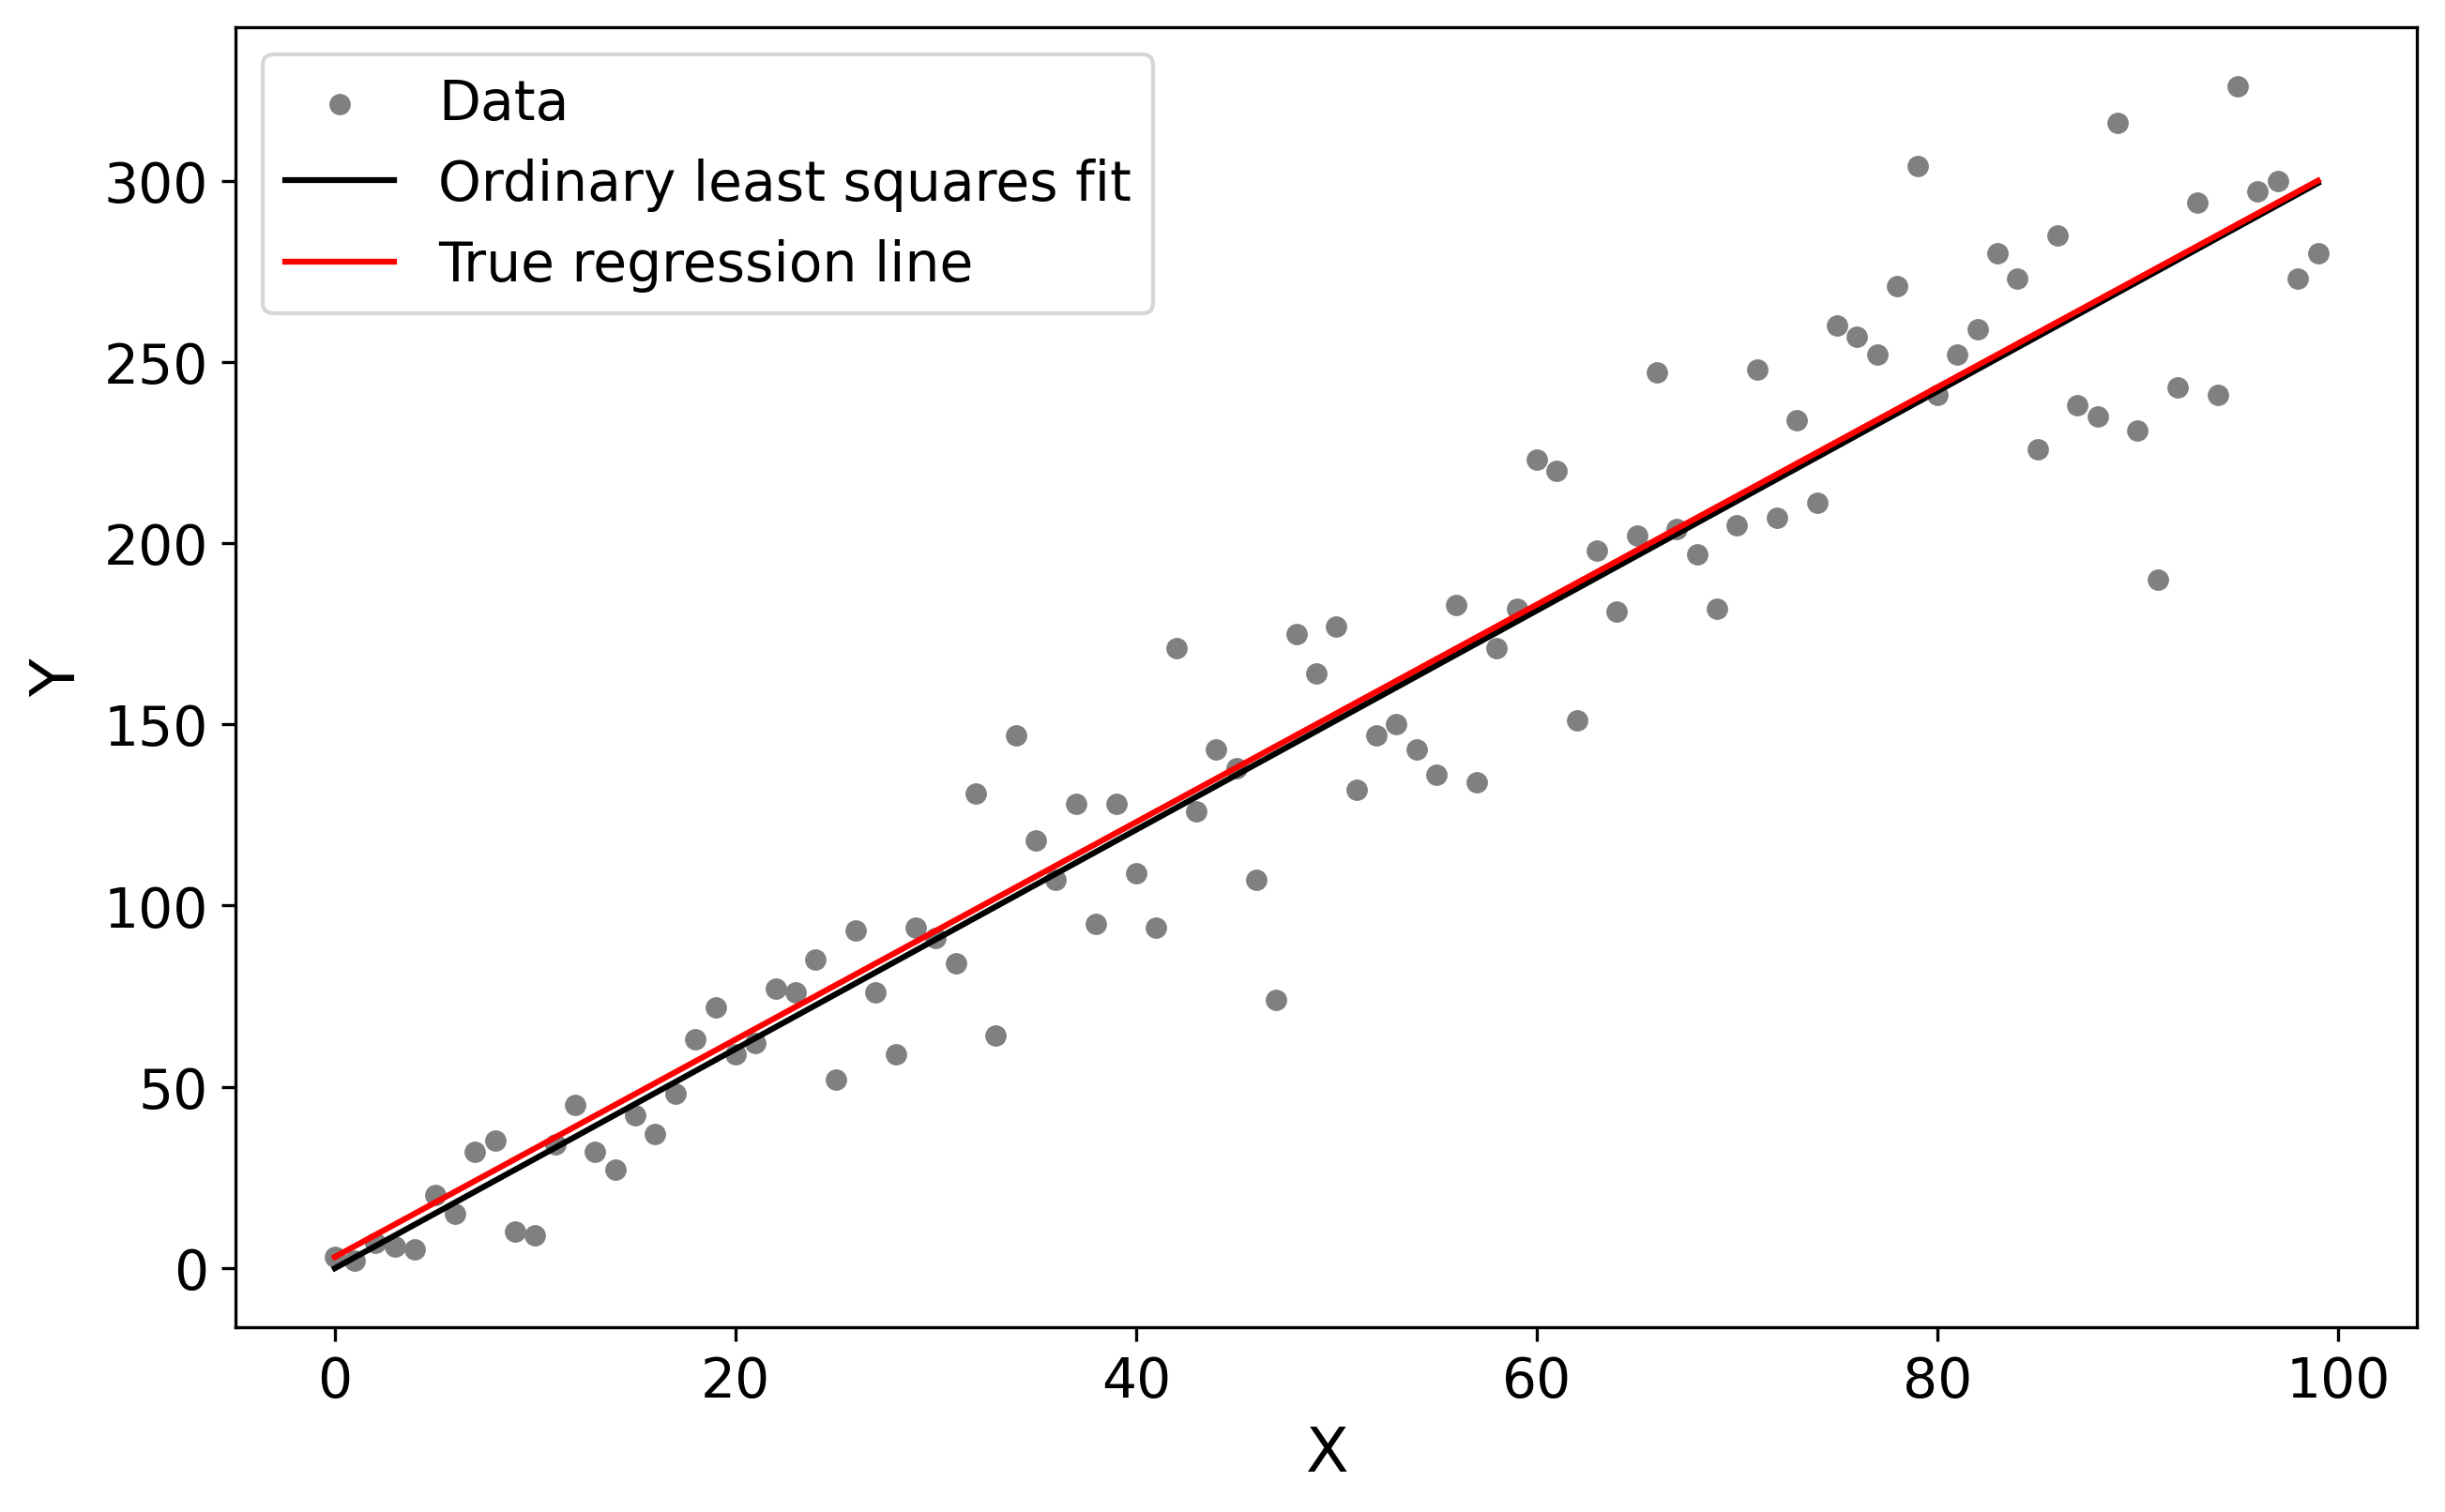

In [8]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Ordinary least squares fit')
plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?
-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?

___
### Respuesta
- No son iguales, esto puede deberse a la alta dispersión de los valores de mayor $x$.
- Representa la razón de cambio de los valores.
___

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [9]:
beta1= np.sum((x-np.mean(x))*(yp-np.mean(yp)))/np.sum((x-np.mean(x))**2)
beta0= np.mean(yp)-beta1*np.mean(x)

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025


___
Son los mismos valores del modelo de regresión lineal.
___

#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [10]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [11]:
scores_r2 = cross_validate(model, x.reshape(-1,1), yp, scoring="r2", return_train_score=True)#implemente una validacion cruzada
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.273 ± 0.319
R2 train: 0.917 ± 0.027


In [12]:
scores_mse = cross_validate(model, x.reshape(-1,1), yp, scoring="neg_mean_squared_error")#implemente una validacion cruzada

scores_mae = cross_validate(model, x.reshape(-1,1), yp, scoring="neg_mean_absolute_error")#implemente una validacion cruzada

print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")

MSE test: 712.979
MAE test: 19.711


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

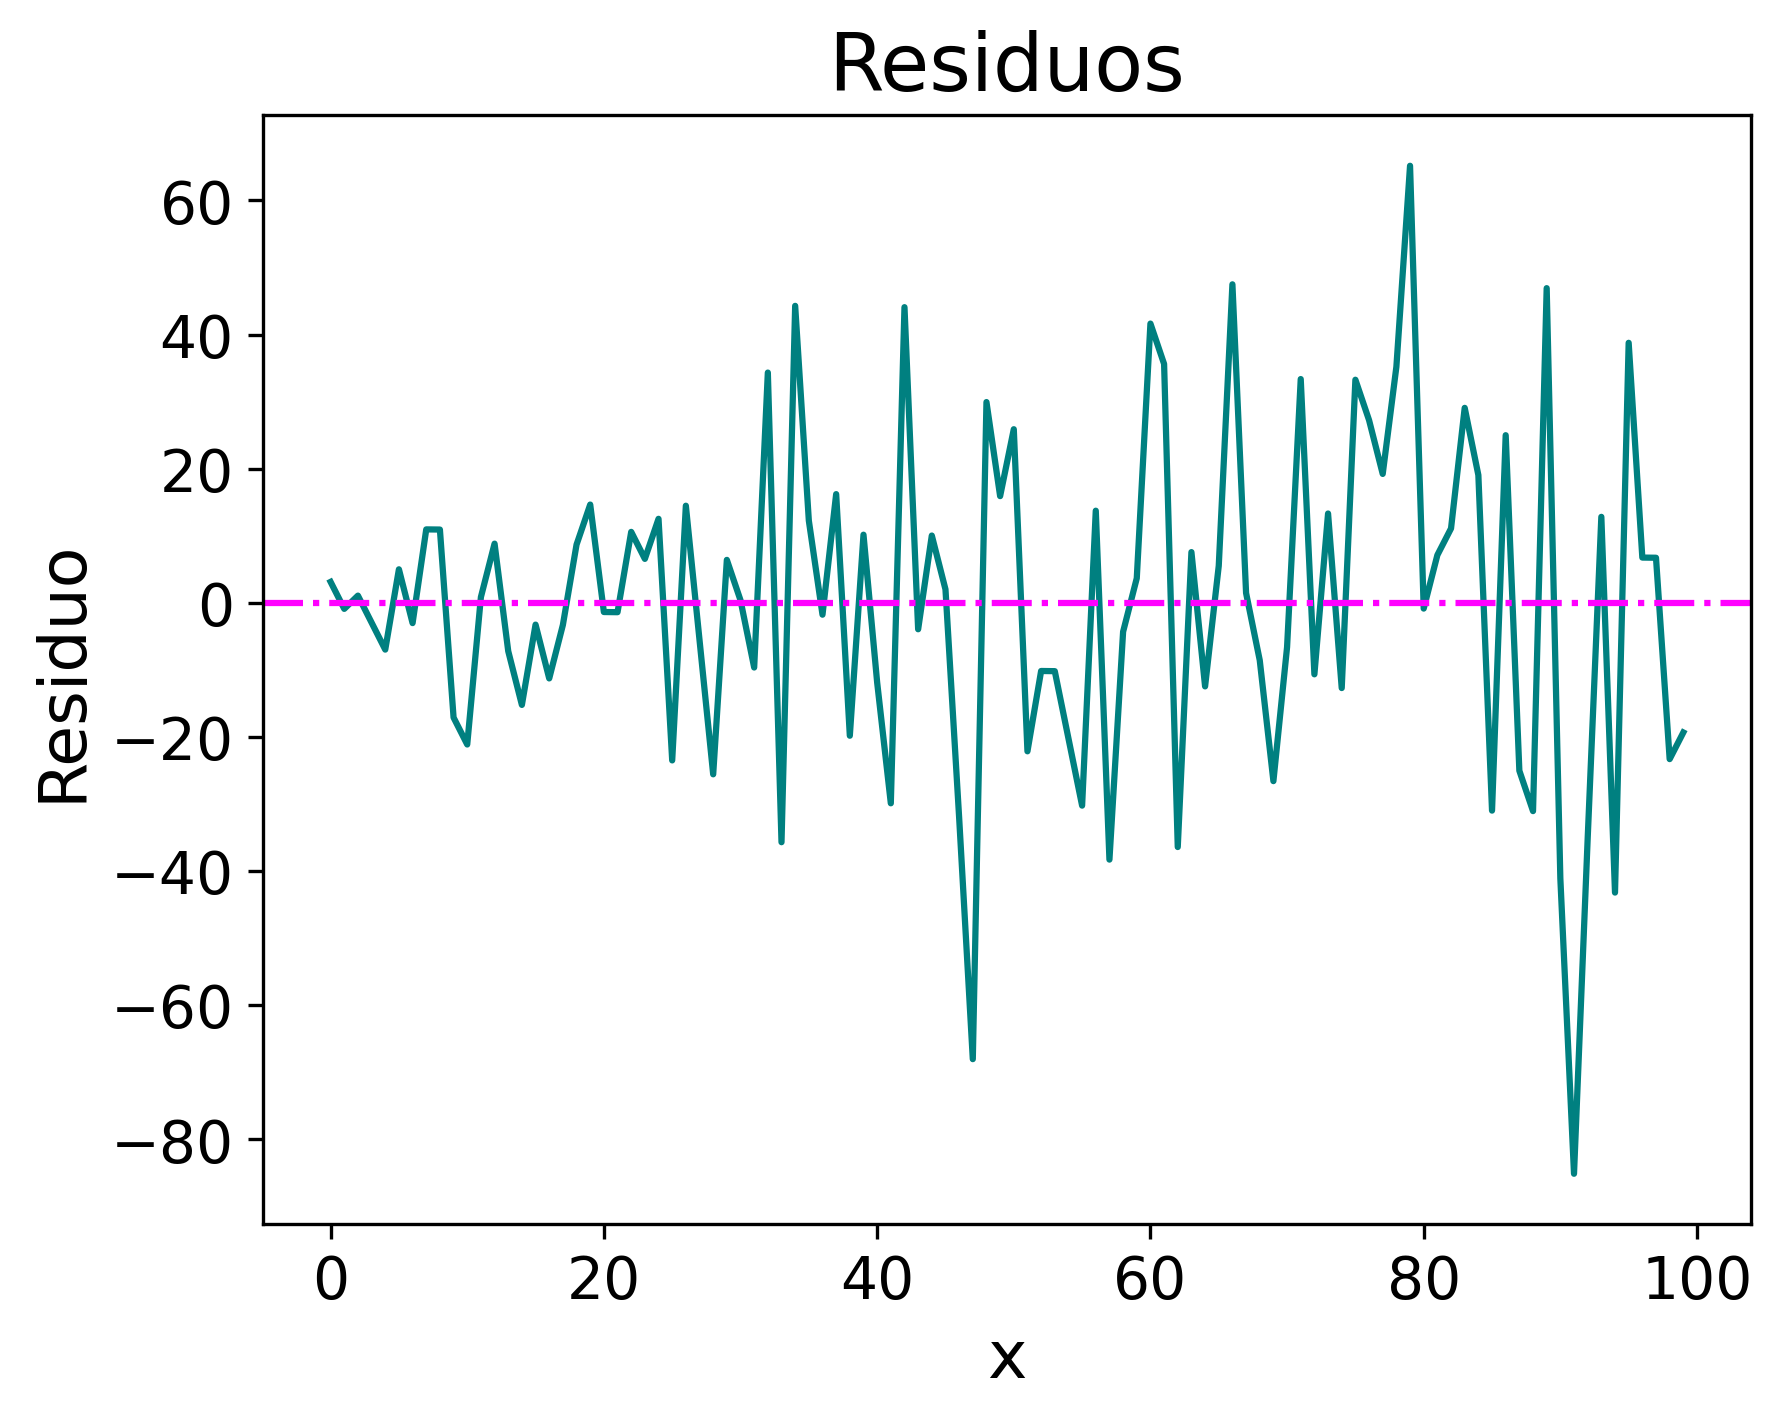

In [13]:
r_i = yp - beta0 - beta1*x

fig1 = plt.figure()
ax1 = fig1.add_subplot()

ax1.plot(x, r_i, c="teal")
ax1.axhline(0, ls="-.", c="magenta")

ax1.set(title="Residuos", xlabel="x", ylabel="Residuo")

plt.show()

#### Pregunta 
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?
-  ¿La dispersión de los residuos cambia con $x$?
-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?

___
### Respuesta
- Sí, parecen ser aleatorios en torno a 0.
- Su dispersión aumenta a medida que aumenta x.
- El modelo va a ser menos preciso a medida que aumenta x, además, los datos fueron generados de forma que aumente la dispersión proporcionalmente a x.
___

### ¿Qué ocurre si agregamos outliers?

In [14]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada 
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

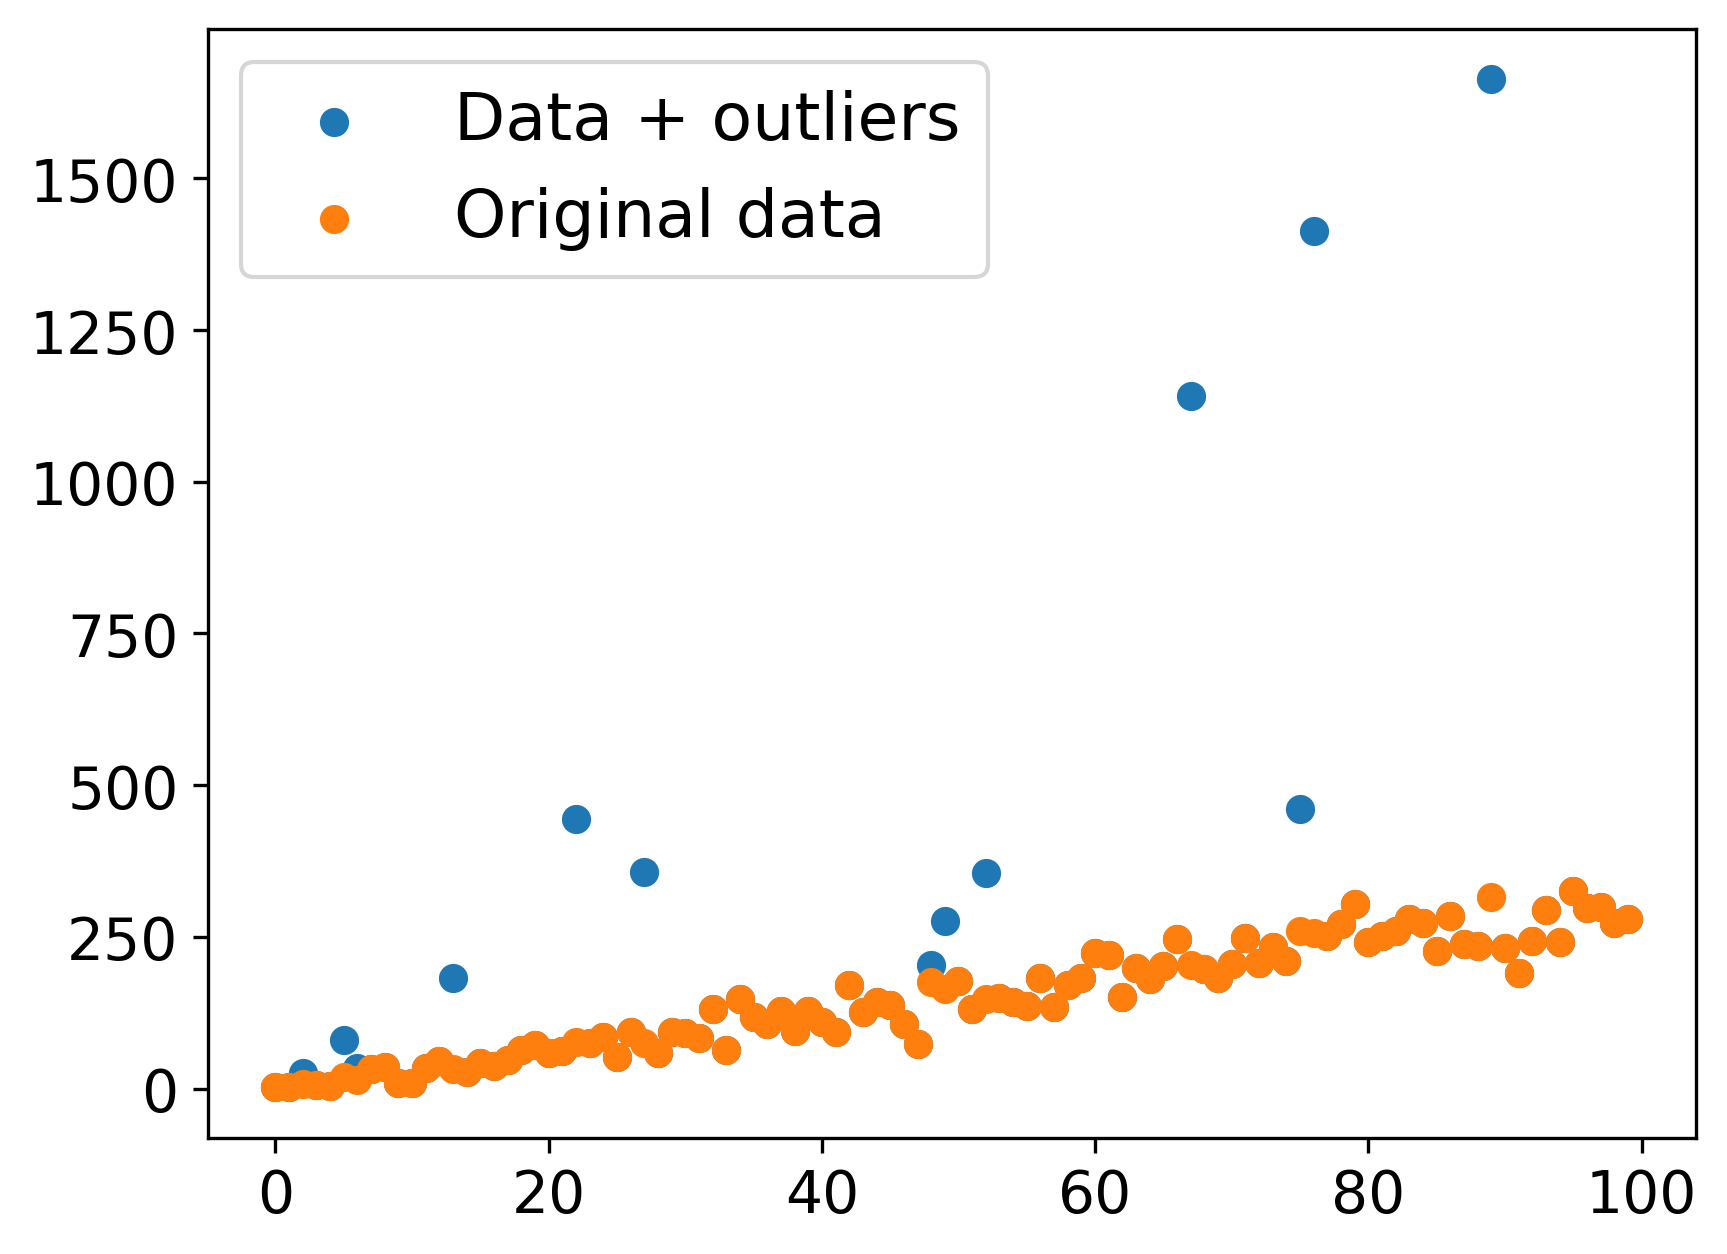

In [15]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda: 
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?
- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?
- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?
- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?
- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.
- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.
- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.

___
### Respuesta
- La recta cambia bastante, aumenta su pendiente. 
- Numéricamente cambia más el intercepto.
- Las métricas son en general peores, además se ve más afectada el MSE.
- Son más sensibles por su factor cuadrático.
- Los outliers más grandes afectar de mayor manera, estos están lejos en $y$.
- El mdoelo está siendo "tirado" hacia arriba. Se puede notar como la pendiente aumenta.
- Primero analizaría su impacto en el modelo antes de eliminarlos.
___

In [16]:
model_outliers = linear_model.LinearRegression()#implemente el modelo aca
model_outliers.fit(x.reshape(-1,1), yp_wo)
slope_outliers = model_outliers.coef_[0]
intercept_outliers = model_outliers.intercept_

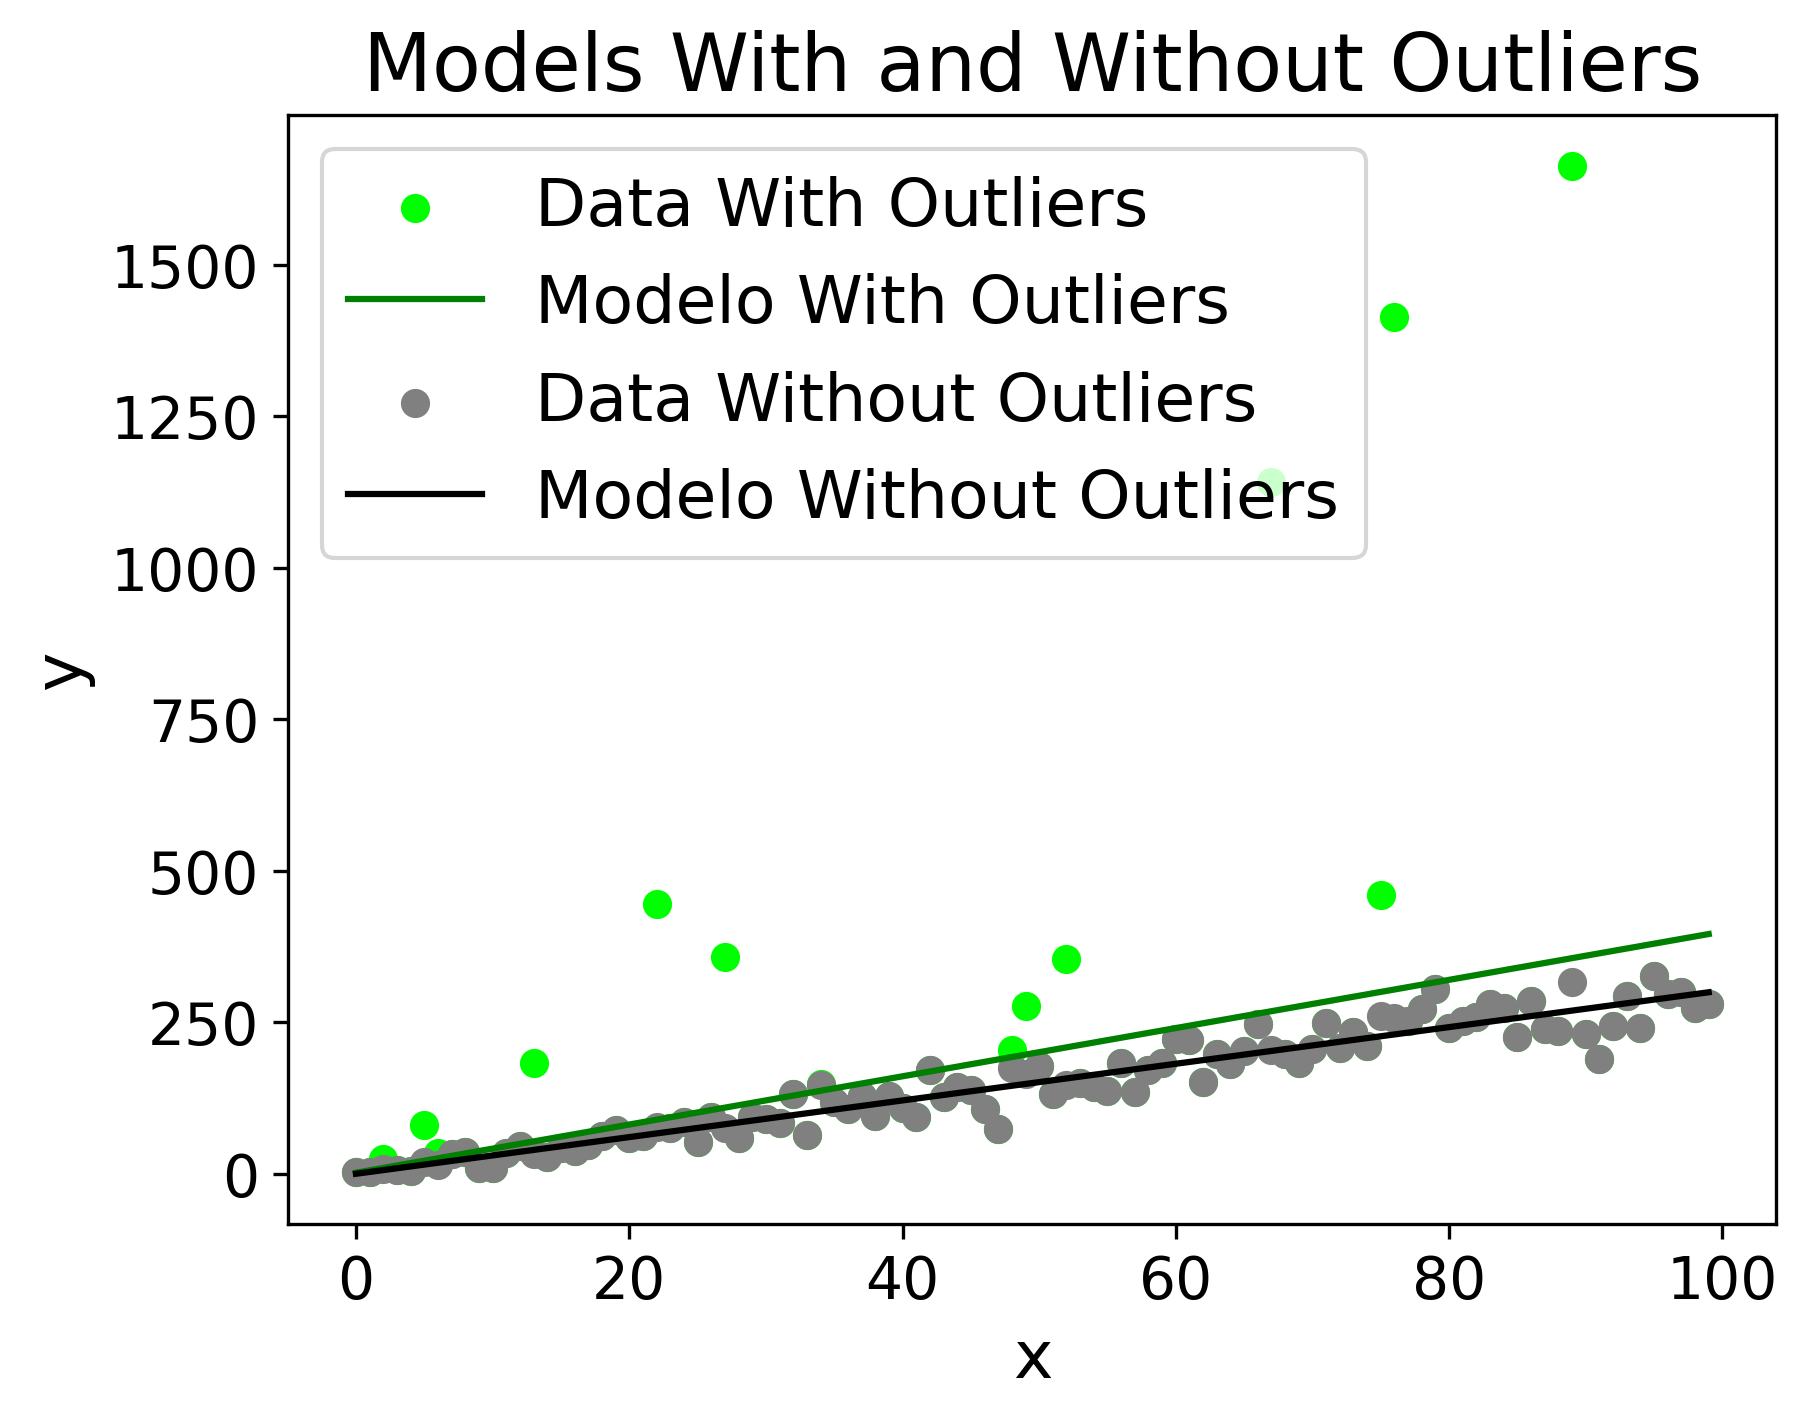

In [17]:
fig2 = plt.figure()
ax2 = fig2.add_subplot()

ax2.scatter(x, yp_wo, c="lime", label="Data With Outliers")
ax2.plot(x, slope_outliers*x+intercept_outliers, c="g", label="Modelo With Outliers")

ax2.scatter(x, yp, c="gray" ,label="Data Without Outliers")
ax2.plot(x, slope*x+intercept, c="black", label="Modelo Without Outliers")

ax2.set(title="Models With and Without Outliers", xlabel="x", ylabel="y")
ax2.legend()

plt.show()

In [18]:
scores_r2_wo = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, scoring="r2")
scores_mse_wo = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, scoring="neg_mean_squared_error")
scores_mae_wo = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, scoring="neg_mean_absolute_error")
scores_rmse = cross_validate(model, x.reshape(-1,1), yp, scoring="neg_root_mean_squared_error")
scores_rmse_wo = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, scoring="neg_root_mean_squared_error")

print("Métricas sin outliers:")
print(f"R^2 test: {scores_r2['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")
print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"RMSE test: {-scores_rmse['test_score'].mean():.3f}")

print("\nMétricas con outliers:")
print(f"R^2 test: {scores_r2_wo['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae_wo['test_score'].mean():.3f}")
print(f"MSE test: {-scores_mse_wo['test_score'].mean():.3f}")
print(f"RMSE test: {-scores_rmse_wo['test_score'].mean():.3f}")

Métricas sin outliers:
R^2 test: 0.273
MAE test: 19.711
MSE test: 712.979
RMSE test: 25.001

Métricas con outliers:
R^2 test: -0.109
MAE test: 95.466
MSE test: 45067.400
RMSE test: 171.781


Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

In [19]:
theta_ne = np.array([[slope_outliers],[intercept_outliers]])

In [39]:
theta_ne

array([[3.97842184],
       [1.54811881]])

Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices 

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [20]:
X = np.c_[np.ones((100, 1)), x]  

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión 

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [21]:
loss_ne = np.mean((X.dot(theta_ne) - yp_wo.reshape(-1,1))**2)

### Batch GD

In [22]:
np.random.seed(10) 

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [23]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [24]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [25]:
loss_bgd

np.float64(43259.08804185896)

In [26]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(30.310266853466768)

###  GD estocástico

In [27]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000005 #learning step, valor más pequeño evita saltos muy grandes

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):
    
        random_index = np.random.randint(m) #índice aleatorio
        
        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)
        
        y_one = yp_wo[random_index:random_index+1] 
        
        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)                 

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [28]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [29]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [30]:
loss_sgd

np.float64(43385.08132655123)

In [31]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(30.10729358736454)

### Mini batch GD

In [ ]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1) 

eta = 0.000005
#eta = 5e-20 prueba eta pequeño
#eta = 100 prueba eta demasiado grande

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta * gradients
    
    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

[[nan]
 [nan]]


/tmp/ipykernel_6911/3171711004.py:31: RuntimeWarning: invalid value encountered in subtract
  theta = theta - eta * gradients


In [33]:
theta_mgd

array([[1.38191988],
       [4.25542902]])

In [34]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [35]:
loss_mgd

np.float64(43506.50418469318)

In [36]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(29.911683208948485)

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

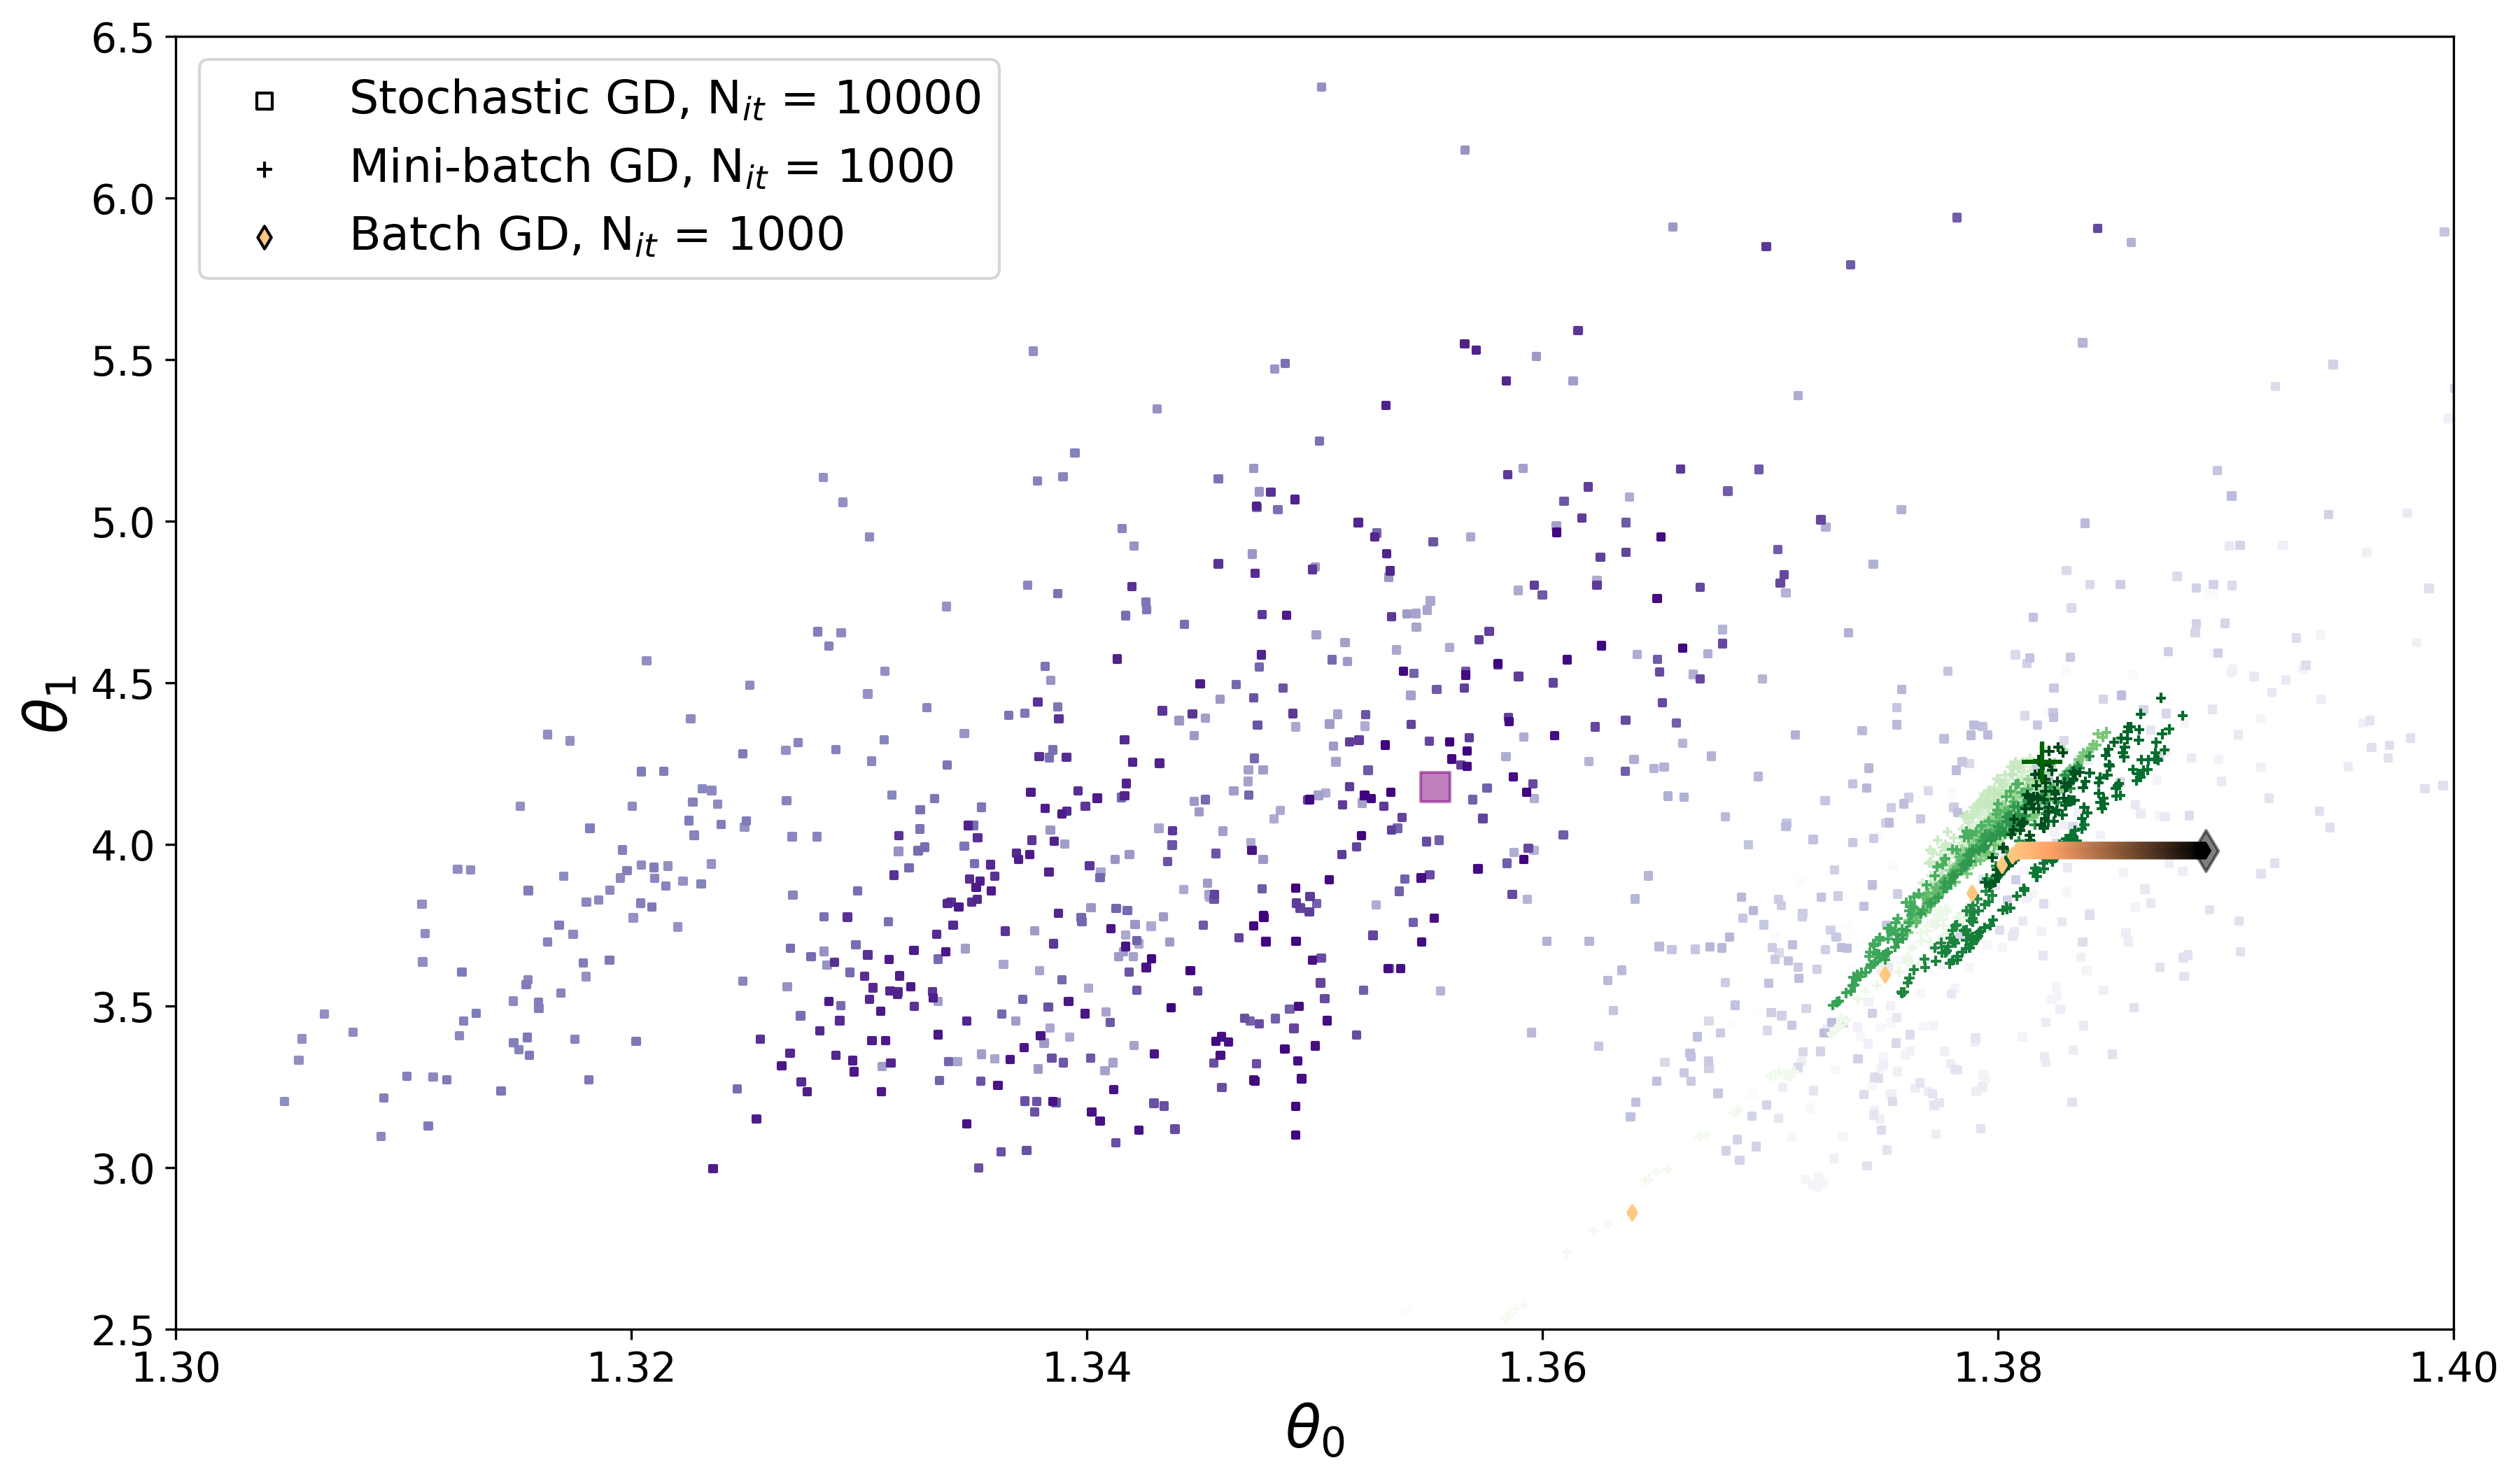

In [37]:
plt.figure(figsize=(14,8))

plt.scatter(theta_path_sgd[::10, 0].flatten(), theta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, N$_{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.scatter(theta_path_mgd[:, 0].flatten(), theta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, N$_{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(theta_path_bgd[:, 0].flatten(), theta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, N$_{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(theta_sgd[0],theta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(theta_mgd[0],theta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(theta_bgd[0],theta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)

legend = plt.legend(loc="upper left", fontsize=16)


for i in range(3):

    legend.legend_handles[i].set_color('k')
    legend.legend_handles[i]._sizes = [30]

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
plt.show()


### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones
   - cálculo del error o residuo
   - cálculo del gradiente
   - actualización de los parámetros

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?


4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?


5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$

6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización?
   - ¿Cuál actualiza los parámetros con más ruido?
   - ¿Cuál parece converger de forma más suave?

___
### Respuestas
1. 
    - Cálculo predicciones: 
    ```
    theta = theta - eta * gradients
    ```
    - Cálculo error o residio: 
    ```
    loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)
    ```
    - Cálculo gradiente: 
    ```
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    ```
    - Actualización parámetros: 
    ```
    theta_path_mgd.append(theta)
    ```
2. $\theta_0$ y $\theta_1$ son los parámetros de regresión.
3. Son parecidos. Pero puede que mini-batch necesite más iteraciones para llegar al mínimo debido al tamaño de eta.
4. Un eta demasiado pequeño requiere más iteraciones para alcanzar el mínimo, mientras que uno demasiado grande diverge. Uno razonable se acerca al valor esperado.
5. El signo *menos* nos permite "movernos" en la dirección opuesta al gradiente, ya que este apunta en la dirección donde la pérdida aumenta y buscamos lo contrario.
6. En *Gradient Descent* calculamos gradientes de valores aleatorios para acercarnos al mínimo.
7. 
    - *Batch Gradient Descent* utiliza todos los datos.
    - *Stochastic Gradient Descent* actualiza con más ruido.
    - *Batch Gradient Descent* converge de forma más suave.
___